# 项目 6：时间序列分析与预测

**项目目标：** 构建一个用于预测未来月度需求的时间序列建模流程。本 notebook 使用的是航空乘客月度数据，它是一个非常适合教学的预测案例；同样的方法也可以迁移到门店销售额、客流量、库存需求等按时间记录的业务指标上。

### 本项目将覆盖的核心概念：

1. **时间序列基础：** 趋势、季节性、周期和残差噪声。
2. **平稳性：** 理解为什么很多预测模型需要稳定的数据结构。
3. **ADF 检验：** 使用 Augmented Dickey-Fuller 检验判断序列是否平稳。
4. **数据变换：** 使用对数变换和差分让序列更接近平稳。
5. **ACF 与 PACF：** 通过自相关图选择 ARIMA 参数。
6. **ARIMA：** 构建非季节性的基线预测模型。
7. **SARIMA：** 在 ARIMA 基础上加入季节性建模能力。
8. **模型评估：** 使用 RMSE 和可视化比较预测值与真实值。

### 理论概念：什么是时间序列？

**时间序列**是一组按时间顺序记录的数据，例如每日销售额、每月访问量或年度收入。与普通表格数据不同，时间序列中观测值的顺序非常重要，因为当前值通常会受到过去值的影响。

时间序列通常可以拆解为四个组成部分：

1. **趋势：** 长期向上或向下的变化方向。
2. **季节性：** 在固定周期内重复出现的模式，例如每年 12 月销售额上升。
3. **周期：** 不一定按固定日历周期重复的长期波动，例如经济周期。
4. **残差：** 去除趋势和季节性后剩下的随机波动。

### 第 1 步：准备环境 - 导入库并加载数据

In [1]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)

In [ ]:
!git clone "https://github.com/HarshvardhanSingh-13/Datasets"

In [4]:
df = pd.read_csv('../Datasets/Airline Timeseries/airline_passenger_timeseries.csv')
df.head(5)

,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


### 第 2 步：探索性数据分析与序列分解

我们先绘制原始时间序列。第一张图通常能帮助我们判断数据是否存在趋势、季节性、方差变化或异常值。

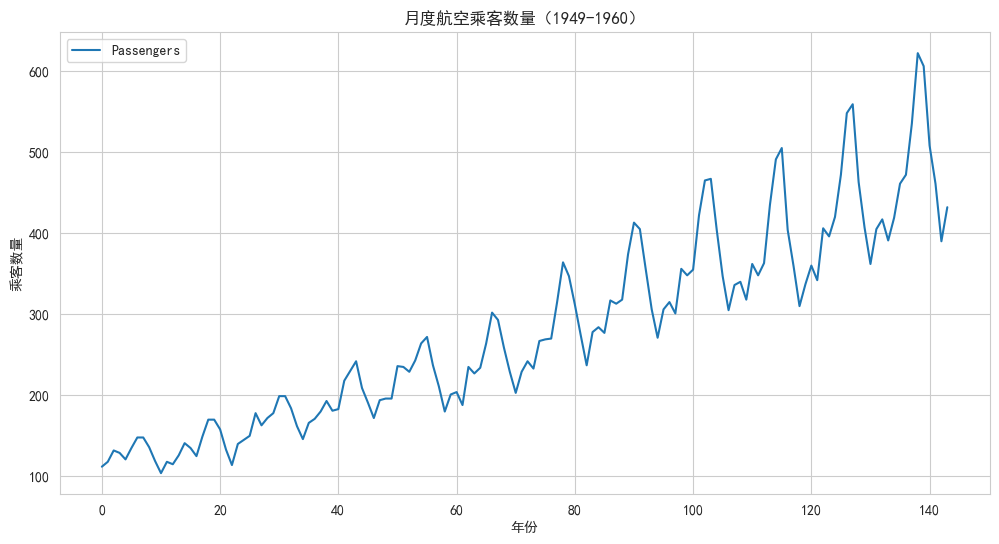

In [5]:
df.plot()
#添加中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

plt.title('月度航空乘客数量（1949-1960）')
plt.xlabel('年份')
plt.ylabel('乘客数量')
plt.show()

**初步观察：** 该序列呈现出三个重要模式：

1. **上升趋势：** 乘客数量随时间增长。
2. **年度季节性：** 每年都会出现重复的峰值和谷值。
3. **方差增大：** 随着整体水平上升，季节性波动幅度也越来越大。

`statsmodels.tsa.seasonal_decompose` 可以把时间序列分解为趋势、季节性和残差。由于这个数据集中季节性波动会随着整体水平增长而变大，因此使用乘法分解更加合适。

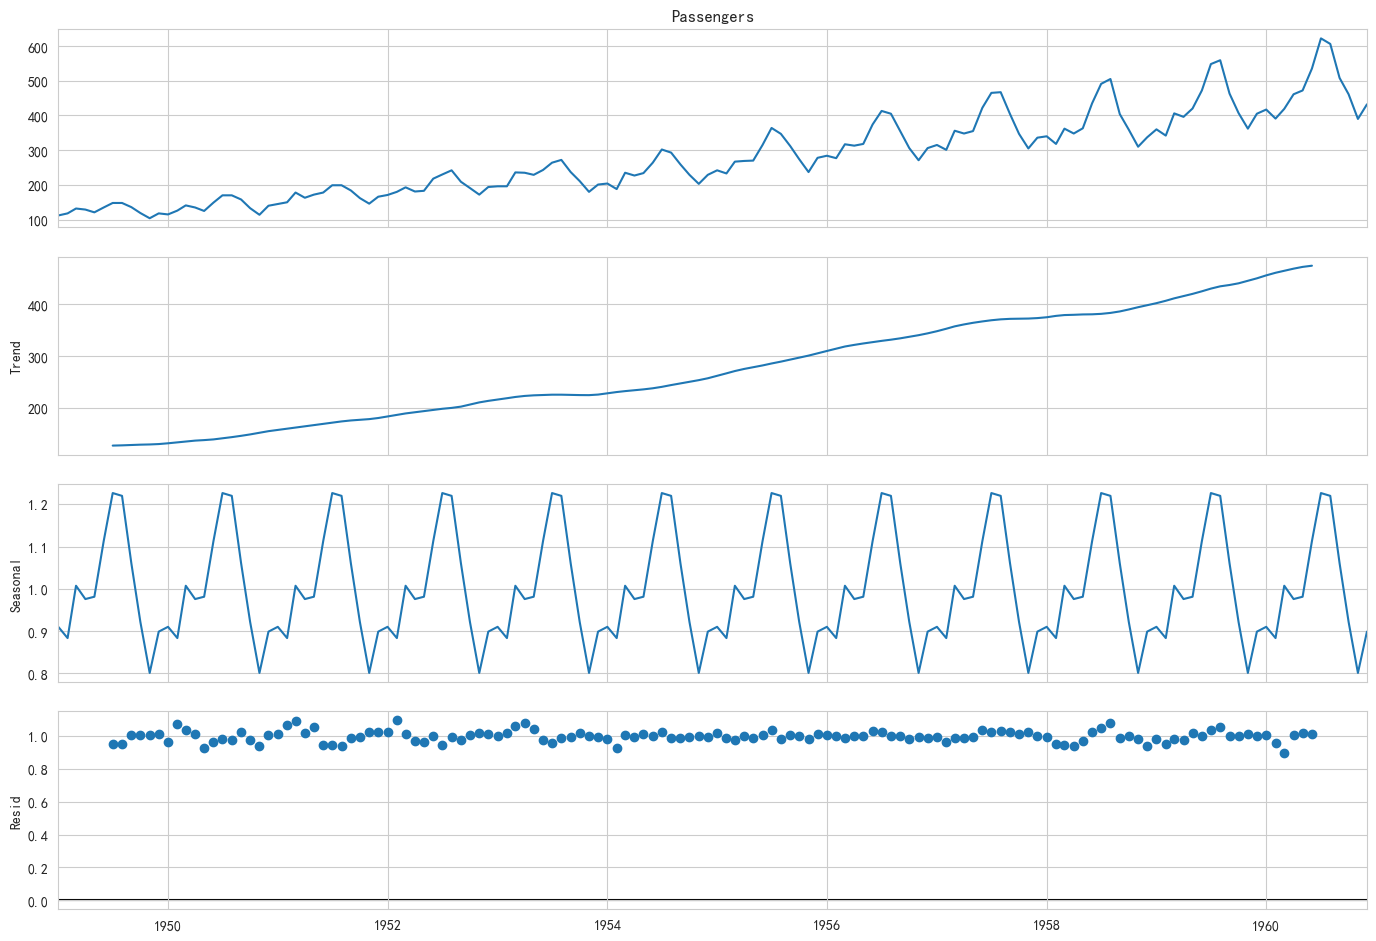

In [6]:
# 将 Month 转为日期格式，并设置为索引
df['Month'] = pd.to_datetime(df['Month'])
df.set_index('Month', inplace=True)

# 分解时间序列，观察趋势、季节性和残差
decomposition = sm.tsa.seasonal_decompose(df['Passengers'], model='multiplicative')

fig = decomposition.plot()
fig.set_size_inches(14, 10)
plt.show()

### 第 3 步：平稳性检验

在构建 ARIMA 类模型之前，我们需要检查序列是否**平稳**。如果序列不平稳，通常需要先进行变换。

#### 理论概念：平稳性

平稳时间序列的统计特征会随时间保持稳定。实际理解时，可以重点看 **均值**、**方差** 和 **自相关结构** 是否稳定。

为什么这很重要：ARIMA 模型依赖过去值和预测误差中的稳定模式。如果均值持续上升，或者季节波动越来越大，模型就可能学习到错误的结构。

我们通常通过两种方式检查平稳性：

1. **视觉检查：** 观察是否存在明显趋势、季节性或方差变化。
2. **ADF 检验：** Augmented Dickey-Fuller 检验会给出 p-value，帮助判断序列是否平稳。

ADF 检验中：

- **原假设：** 序列不平稳。
- **备择假设：** 序列平稳。
- 如果 `p-value < 0.05`，通常拒绝原假设，认为序列已经较为平稳。

#### 如何阅读 ADF 检验结果

最重要的指标是 **p-value**。如果 p-value 很小，通常小于 `0.05`，说明序列更可能是平稳的。如果 p-value 很大，说明我们没有足够证据拒绝“非平稳”的原假设。

检验统计量和临界值提供了另一种判断方式：如果检验统计量比某个临界值更小，也就是更负，那么结果支持在对应置信水平下认为序列平稳。

In [7]:
def test_stationarity(timeseries):
    # 执行 Dickey-Fuller 检验
    print('Dickey-Fuller 检验结果:')
    dftest = adfuller(timeseries, autolag='AIC')
    dfoutput = pd.Series(dftest[0:4], index=['Test Statistic', 'p-value', '#Lags Used', 'Number of Observations Used'])
    for key, value in dftest[4].items():
        dfoutput['Critical Value (%s)' % key] = value
    print(dfoutput)

test_stationarity(df['Passengers'])

Dickey-Fuller 检验结果:
Test Statistic                   0.815369
p-value                          0.991880
#Lags Used                      13.000000
Number of Observations Used    130.000000
Critical Value (1%)             -3.481682
Critical Value (5%)             -2.884042
Critical Value (10%)            -2.578770
dtype: float64


`adfuller(timeseries, autolag='AIC')` 会运行 ADF 检验。`autolag='AIC'` 表示使用 AIC 准则自动选择合适的滞后阶数。

**结果：** p-value 很高，约为 `0.99`，因此我们不能拒绝原假设。原始序列是非平稳的，需要先进行变换再构建 ARIMA 模型。

### 第 4 步：让序列变得平稳

这里使用两种常见变换：

1. **对数变换：** 当波动幅度随着序列水平增长而增大时，对数变换可以稳定方差。
2. **差分：** 用当前值减去前一个值，帮助去除趋势。

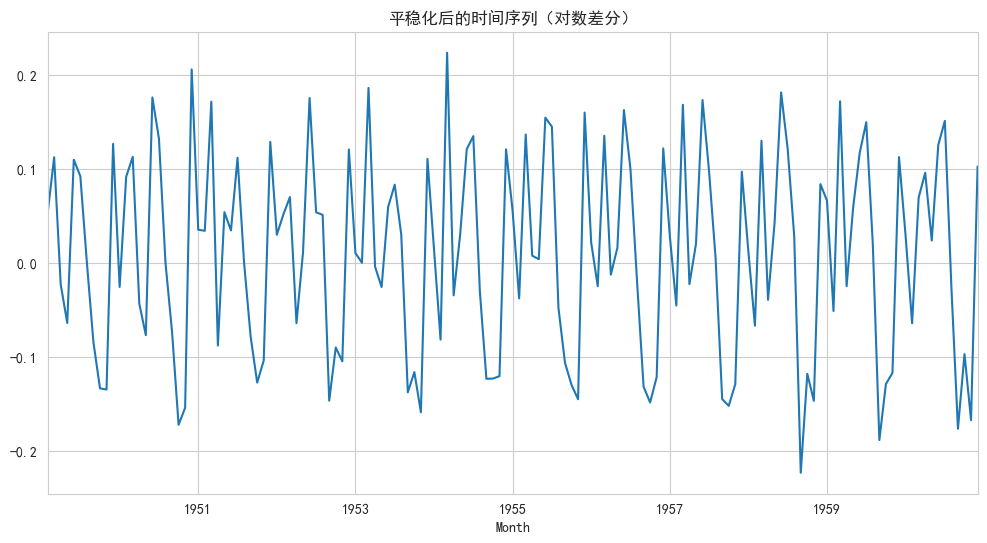

Dickey-Fuller 检验结果:
Test Statistic                  -2.717131
p-value                          0.071121
#Lags Used                      14.000000
Number of Observations Used    128.000000
Critical Value (1%)             -3.482501
Critical Value (5%)             -2.884398
Critical Value (10%)            -2.578960
dtype: float64


In [8]:
# 1. 使用对数变换稳定方差
df_log = np.log(df['Passengers'])

# 2. 使用差分去除趋势
df_diff = df_log.diff().dropna()

# 绘制变换后的序列
df_diff.plot()
plt.title('平稳化后的时间序列（对数差分）')
plt.show()

# 再次检验平稳性
test_stationarity(df_diff)

### ACF 与 PACF 的直觉理解

- **ACF：** 衡量序列与其滞后版本之间的相关性。
- **PACF：** 在排除中间滞后影响后，衡量当前值与某个滞后值之间的直接相关性。

这两个图可以帮助我们选择 ARIMA 的 `p` 和 `q` 参数。

对于 ARIMA：

- **`p`** 通常参考 PACF 图。
- **`d`** 表示差分次数。
- **`q`** 通常参考 ACF 图。

### 第 5 步：使用 ACF 和 PACF 识别模型参数

#### 理论概念：ACF 与 PACF

自相关图可以总结当前值与过去值之间的关系。

- **ACF** 帮助识别移动平均项，也就是 `q`。
- **PACF** 帮助识别自回归项，也就是 `p`。
- 因为我们对对数序列做了一次差分，所以先设定 `d = 1`。

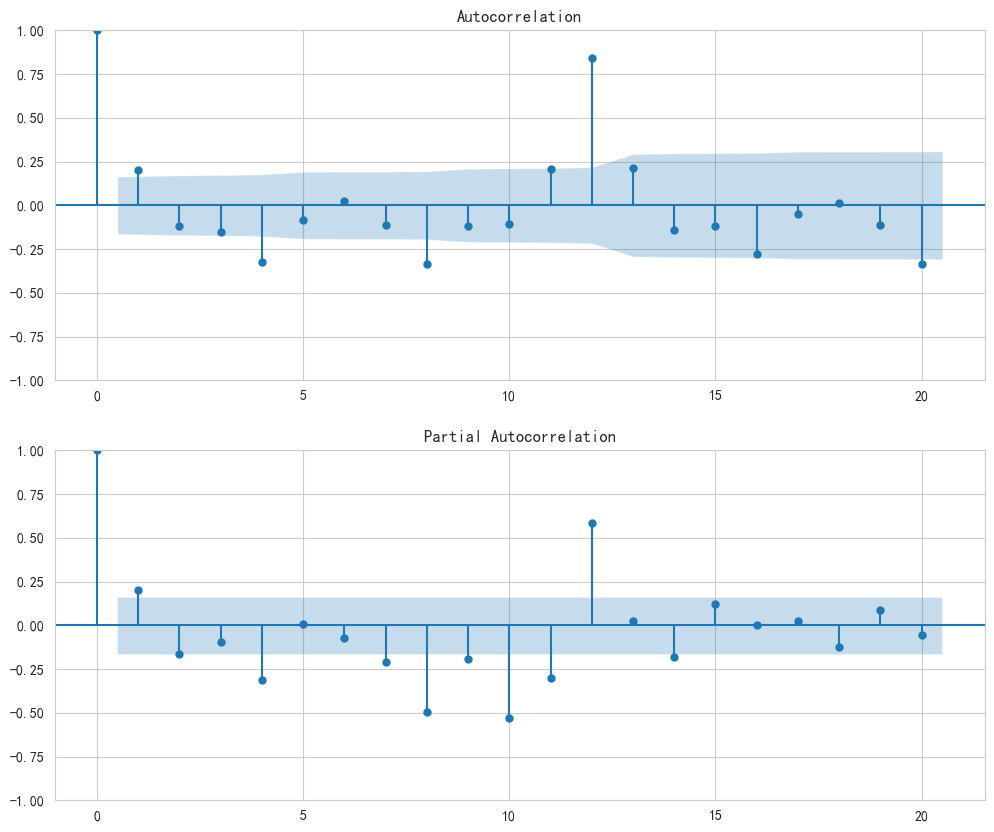

In [9]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))
plot_acf(df_diff, ax=ax1, lags=20)
plot_pacf(df_diff, ax=ax2, lags=20)
plt.show()

**解释：** PACF 在滞后 1 附近明显截尾，提示 `p = 1`。ACF 也在滞后 1 之后减弱，提示 `q = 1`。因此，一个合理的基线模型是 **ARIMA(1, 1, 1)**。

## 理论概念：ARIMA

**ARIMA** 是 AutoRegressive Integrated Moving Average 的缩写，通常写作 **ARIMA(p, d, q)**：

- **p：** 自回归滞后项数量。
- **d：** 为了让序列平稳而进行的差分次数。
- **q：** 移动平均误差项数量。

ARIMA 适合处理带趋势的时间序列，但基础 ARIMA 不会显式建模季节性。

### 第 6 步：构建 ARIMA 模型

d:\app\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


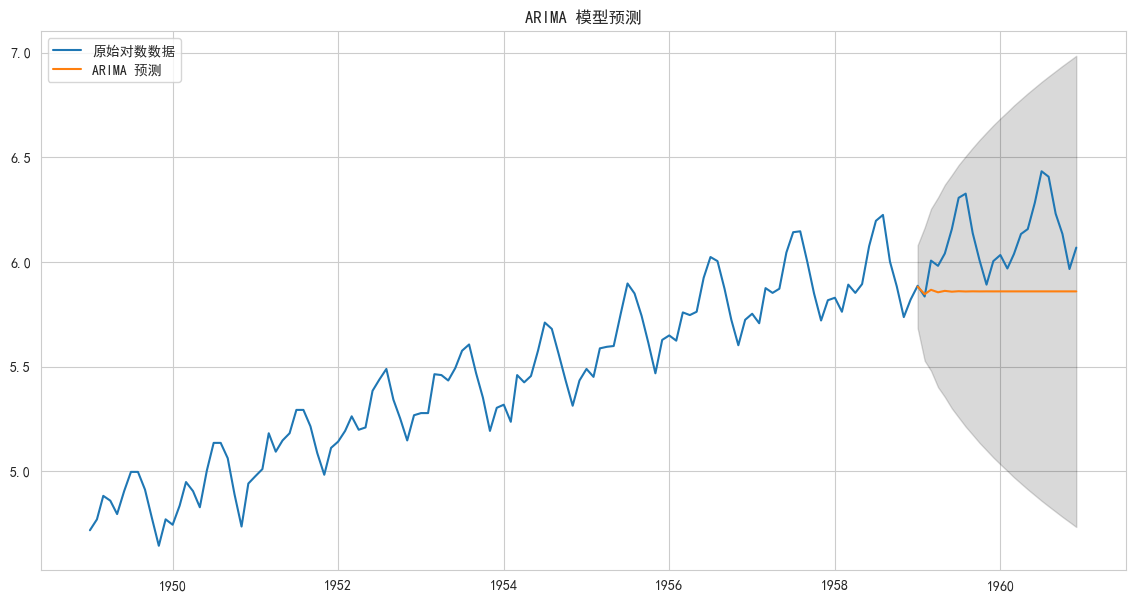

In [10]:
# 划分训练集和测试集
train_data = df_log[:'1958']
test_data = df_log['1959':]

# 构建 ARIMA 模型
model = ARIMA(train_data, order=(1, 1, 1), freq='MS')
arima_result = model.fit()

# 生成预测
forecast = arima_result.get_forecast(steps=len(test_data))
forecast_ci = forecast.conf_int()

# 绘制预测结果
plt.figure(figsize=(14, 7))
plt.plot(df_log, label='原始对数数据')
plt.plot(forecast.predicted_mean, label='ARIMA 预测')
plt.fill_between(forecast_ci.index, forecast_ci.iloc[:, 0], forecast_ci.iloc[:, 1], color='k', alpha=.15)
plt.title('ARIMA 模型预测')
plt.legend()
plt.show()

**ARIMA 结果：** 模型能够跟随整体趋势，但没有捕捉到重复出现的季节性峰值和谷值。这是因为普通 ARIMA 不包含季节性组件。

### 第 7 步：构建用于季节性的 SARIMA 模型

#### 理论概念：SARIMA

**SARIMA** 在 ARIMA 基础上加入了季节性项，通常写作 **SARIMA(p, d, q)(P, D, Q, m)**。

- `(p, d, q)` 是非季节性的 ARIMA 参数。
- `(P, D, Q)` 分别表示季节性的自回归、差分和移动平均参数。
- `m` 是一个季节周期包含的时间步数。对于具有年度季节性的月度数据，`m = 12`。

当数据同时具有趋势和重复季节性时，SARIMA 通常比普通 ARIMA 更合适。

d:\app\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


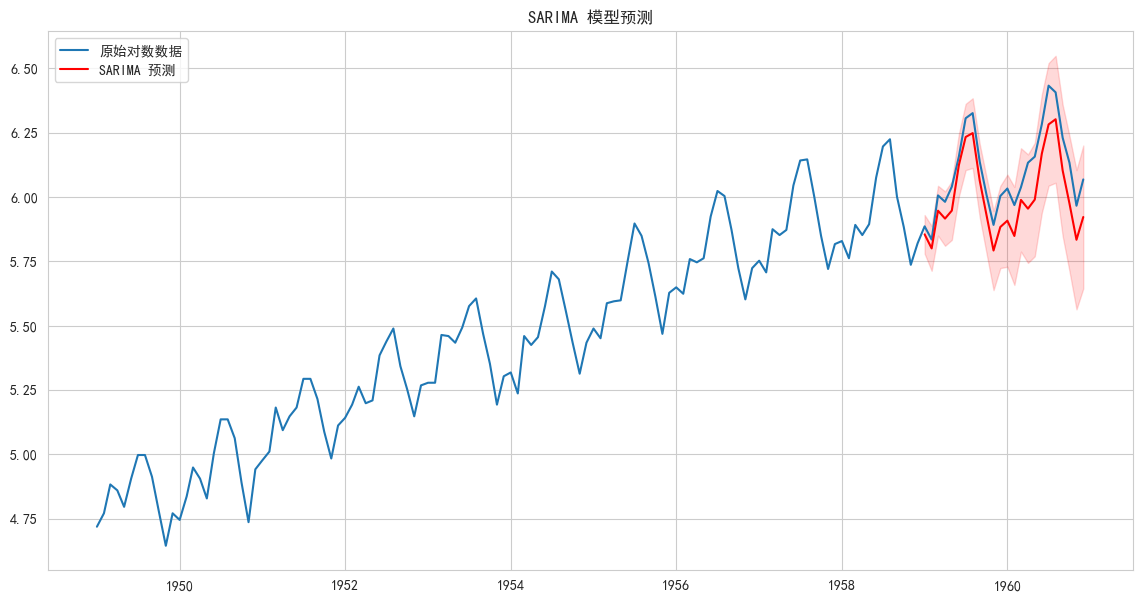

In [11]:
# 构建 SARIMA 模型
# P、D、Q 可以通过网格搜索寻找，这里先使用常见起点 1。
sarima_model = sm.tsa.statespace.SARIMAX(train_data,
                                          order=(1, 1, 1),
                                          seasonal_order=(1, 1, 1, 12),
                                          enforce_stationarity=False,
                                          enforce_invertibility=False,
                                          freq='MS')
sarima_result = sarima_model.fit()

# 生成预测
sarima_forecast = sarima_result.get_forecast(steps=len(test_data))
sarima_forecast_ci = sarima_forecast.conf_int()

# 绘制预测结果
plt.figure(figsize=(14, 7))
plt.plot(df_log, label='原始对数数据')
plt.plot(sarima_forecast.predicted_mean, label='SARIMA 预测', color='red')
plt.fill_between(sarima_forecast_ci.index, sarima_forecast_ci.iloc[:, 0], sarima_forecast_ci.iloc[:, 1], color='r', alpha=.15)
plt.title('SARIMA 模型预测')
plt.legend()
plt.show()

**SARIMA 结果：** 这是一个明显改进。模型同时捕捉到了上升趋势和每年的季节性峰谷。

### 第 8 步：最终评估

SARIMA 模型 RMSE: 48.24


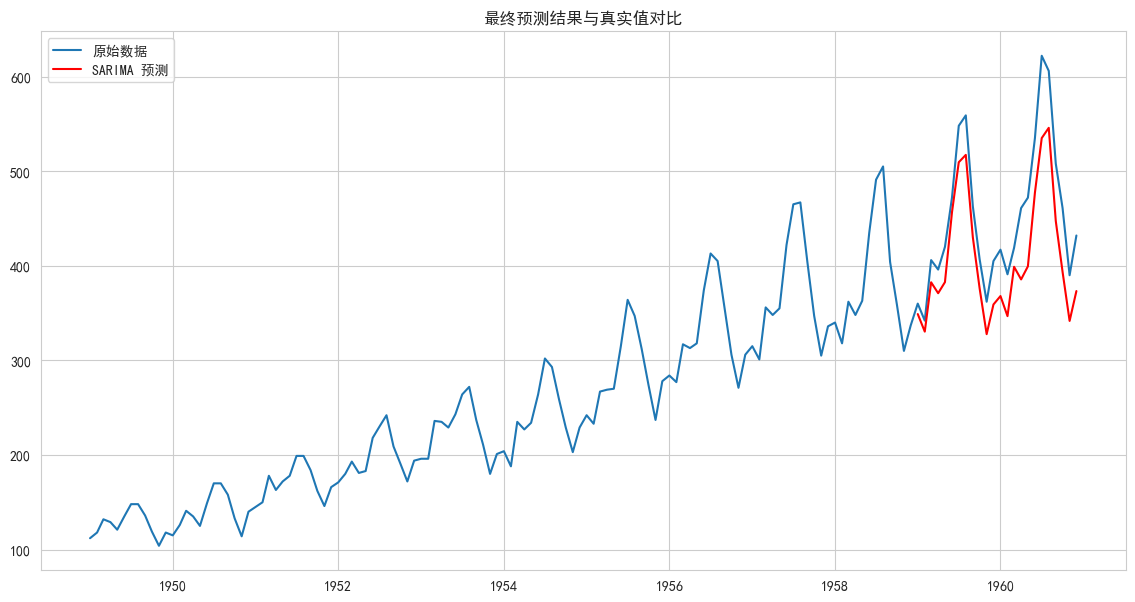

In [12]:
# 还原对数变换，得到真实乘客数量尺度
original_test_data = np.exp(test_data)
sarima_predictions = np.exp(sarima_forecast.predicted_mean)

# 计算 RMSE
rmse = np.sqrt(mean_squared_error(original_test_data, sarima_predictions))
print(f"SARIMA 模型 RMSE: {rmse:.2f}")

# 绘制最终结果
plt.figure(figsize=(14, 7))
plt.plot(df['Passengers'], label='原始数据')
plt.plot(sarima_predictions, label='SARIMA 预测', color='red')
plt.title('最终预测结果与真实值对比')
plt.legend()
plt.show()

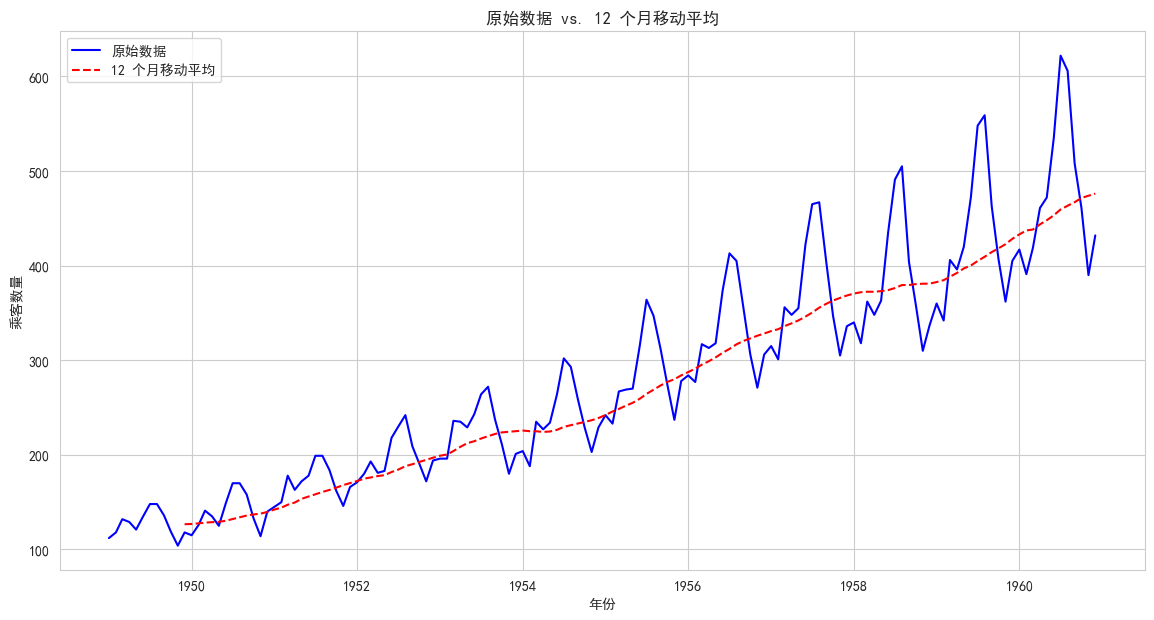

In [13]:
# 计算 12 个月移动平均
df['MovingAverage'] = df['Passengers'].rolling(window=12).mean()

# 绘制原始数据和移动平均
plt.figure(figsize=(14, 7))
plt.plot(df['Passengers'], label='原始数据', color='blue')
plt.plot(df['MovingAverage'], label='12 个月移动平均', color='red', linestyle='--')
plt.title('原始数据 vs. 12 个月移动平均')
plt.xlabel('年份')
plt.ylabel('乘客数量')
plt.legend()
plt.show()

d:\app\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\app\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


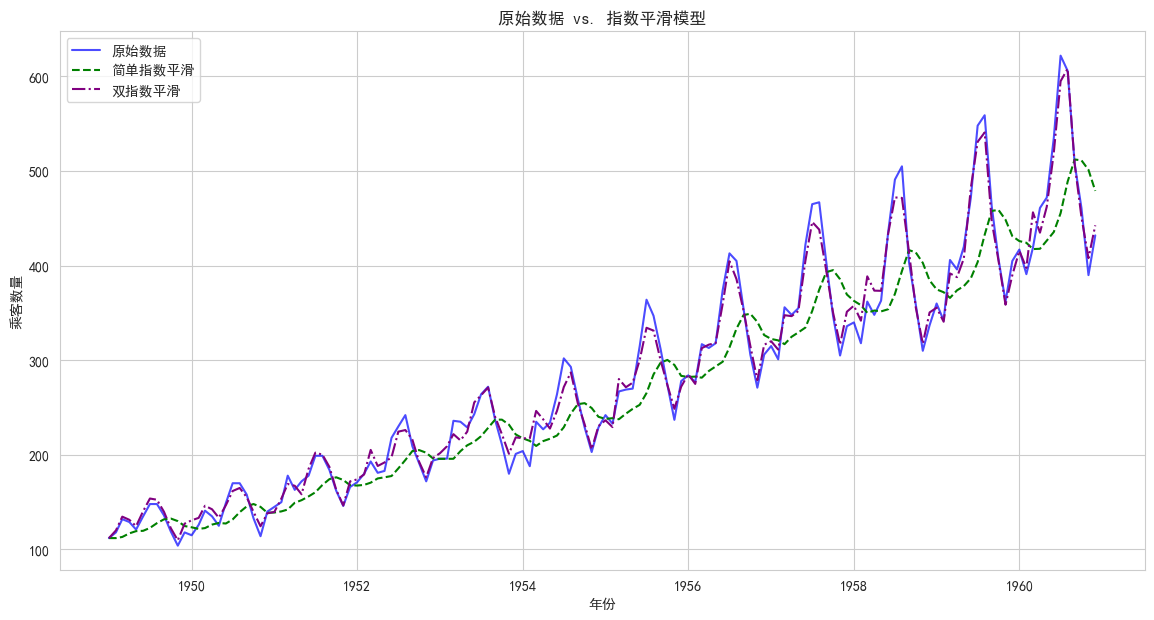

In [14]:
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, ExponentialSmoothing

# 拟合简单指数平滑模型
ses_model = SimpleExpSmoothing(df['Passengers']).fit(smoothing_level=0.2, optimized=False)
df['SimpleExpSmoothing'] = ses_model.fittedvalues

# 拟合带趋势和季节性的指数平滑模型
des_model = ExponentialSmoothing(df['Passengers'], trend='add', seasonal='add', seasonal_periods=12).fit()
df['DoubleExpSmoothing'] = des_model.fittedvalues

# 绘制原始数据和两个平滑模型的拟合值
plt.figure(figsize=(14, 7))
plt.plot(df['Passengers'], label='原始数据', color='blue', alpha=0.7)
plt.plot(df['SimpleExpSmoothing'], label='简单指数平滑', color='green', linestyle='--')
plt.plot(df['DoubleExpSmoothing'], label='双指数平滑', color='purple', linestyle='-.')
plt.title('原始数据 vs. 指数平滑模型')
plt.xlabel('年份')
plt.ylabel('乘客数量')
plt.legend()
plt.show()

### 平滑方法与 ARIMA/SARIMA 的对比

我们比较了几类预测思路：

- **移动平均：** 能平滑短期噪声并展示趋势，但会滞后，且不能很好预测季节性。
- **指数平滑：** 更重视近期观测值。简单指数平滑适合稳定数据，带趋势的平滑方法可以跟随上升趋势。
- **ARIMA：** 在差分后建模自相关结构，但默认不处理季节性。
- **SARIMA：** 加入季节性结构，更适合具有年度重复模式的数据。

d:\app\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
d:\app\anaconda\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


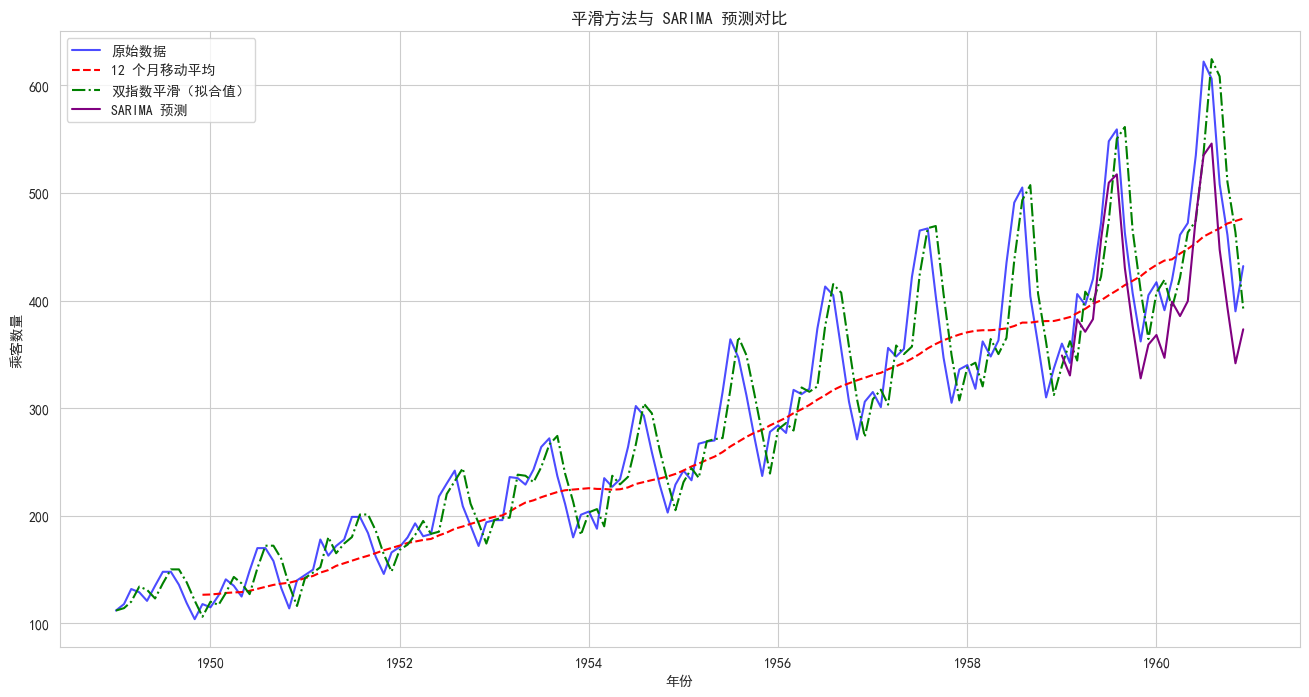

In [15]:
# 使用双指数平滑进行对比
from statsmodels.tsa.holtwinters import ExponentialSmoothing

# 在完整数据上拟合双指数平滑，便于可视化比较
double_exp_smoothing_model = ExponentialSmoothing(df['Passengers'], trend='add', seasonal=None)
double_exp_smoothing_fit = double_exp_smoothing_model.fit()
df['DoubleExpSmoothing'] = double_exp_smoothing_fit.fittedvalues

# 对比原始数据、移动平均、双指数平滑和 SARIMA 预测
plt.figure(figsize=(16, 8))
plt.plot(df['Passengers'], label='原始数据', color='blue', alpha=0.7)
plt.plot(df['MovingAverage'], label='12 个月移动平均', color='red', linestyle='--')
plt.plot(df['DoubleExpSmoothing'], label='双指数平滑（拟合值）', color='green', linestyle='-.')

train_data = df_log[:'1958']
test_data = df_log['1959':]
sarima_model = sm.tsa.statespace.SARIMAX(train_data,
                                          order=(1, 1, 1),
                                          seasonal_order=(1, 1, 1, 12),
                                          enforce_stationarity=False,
                                          enforce_invertibility=False,
                                          freq='MS')
sarima_result = sarima_model.fit()
sarima_forecast = sarima_result.get_forecast(steps=len(test_data))
sarima_predictions_plot = np.exp(sarima_forecast.predicted_mean)

plt.plot(sarima_predictions_plot, label='SARIMA 预测', color='purple')
plt.title('平滑方法与 SARIMA 预测对比')
plt.xlabel('年份')
plt.ylabel('乘客数量')
plt.legend()
plt.show()

#### 可视化对比总结

移动平均适合观察长期趋势，但存在滞后并且无法捕捉季节性。双指数平滑对趋势反应更快，但仍然难以处理重复的季节性峰值。SARIMA 在这里表现最好，因为它同时建模了趋势和季节性。

#### 为什么平稳性很重要

平稳性很重要，因为许多时间序列模型都假设未来会以一种稳定方式延续过去的模式。如果均值、方差或自相关结构随时间变化，模型可能学到无法泛化到未来的规律。

在本项目中，原始序列不平稳，因此我们先使用对数变换和差分，再拟合 ARIMA。随后 SARIMA 进一步加入季节性差分和季节性参数，更好地表示年度周期。

## 提交标准

为了完成本项目，请确保 notebook 包含以下内容：

1. 对序列进行变换，使 ADF 检验的 p-value 小于 `0.05`。
2. 在平稳序列上构建 ARIMA 模型。
3. 对比 ARIMA 与 SARIMA，并解释为什么季节性模型更适合这个数据集。
4. 提交包含图表、模型输出和文字解释的完整 notebook。